### Collab Code at:

<a href="https://colab.research.google.com/github/tikadatta2005/CSC60904-Deep-Learning-T3/blob/main/experiments/DeepLearning_GroupAssignment_Yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

### Basic Environmental Config

In [2]:
IMAGE_SIZE = 112
BATCH_SIZE = 32
EPOCHS = 30
SEED = 41

### Model Training
- Load pretrained YOLOv8 Nano classification model (transfer learning)
- Apply augmentation suited to hand-sign images (no left-right flip — it would change which character a hand shape represents)
- Train and save

In [3]:
from ultralytics import YOLO, settings

In [4]:
model = YOLO("yolov8n-cls.pt")
print("Pretrained YOLOv8 Nano classification model loaded.")

Pretrained YOLOv8 Nano classification model loaded.


In [5]:
from pathlib import Path

project_path = Path("../documentations/experiments")

print(project_path.resolve())

C:\Projects\ai_projects\Devnagari_Sign_Language\documentations\experiments


In [6]:
import pandas as pd

In [ ]:
results = model.train(
    data="../datasets/final_dataset",
    imgsz=112,
    batch=BATCH_SIZE,
    epochs=EPOCHS,
    seed=SEED,

    # Geometric augmentation
    degrees=10,          # Random rotation: approximately ±10°
    translate=0.05,      # Random translation: ±5%
    scale=0.1,           # Random scale: approximately 0.9× to 1.1×

    # Color augmentation
    hsv_h=0.0,           # No hue change
    hsv_s=0.0,           # No saturation change
    hsv_v=0.2,           # Brightness-like variation

    # No flipping
    fliplr=0.0,
    flipud=0.0,

    # Disable other augmentation methods
    shear=0.0,
    perspective=0.0,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,

    # Save every epoch
    save=True,
    save_period=1,
    
    # Optimizer
    optimizer="SGD",
    lr0=2e-3,
    lrf=1.0,
    momentum=0.9,
    weight_decay=3e-5,
    cos_lr=False,
    

    project=str(project_path.resolve()),
    name="anuj-yolo"
)

print("Training completed.")

Model trained for 30 epochs with augmentation tuned for hand-gesture images; results saved to `/content/NSL_YOLOv8_Results/YOLOv8_NSLv2`.


### Training Performance Analysis
- the model creates metrics but doesnot provide all 4 metrics every epoch
- so each epoch will be loaded
- for each epoch it will be tested on training set and val set to observe model performance

In [7]:
# load libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F

In [8]:
torch.manual_seed(SEED)
# create train and val set for inference
train_transforms = transforms.Compose([
     transforms.Resize((112, 112)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
])

transform = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor()
])

train_data_set = datasets.ImageFolder("../datasets/final_dataset/train", transform=train_transforms)
val_data_set = datasets.ImageFolder("../datasets/final_dataset/val", transform=transform)

train = DataLoader(
    train_data_set, 
    batch_size=32, 
    num_workers=4, 
    persistent_workers=True, 
    pin_memory=True, 
    shuffle=True
    )

val = DataLoader(
    val_data_set,
    batch_size=32, 
    num_workers=4, 
    persistent_workers=True, 
    pin_memory=True, 
)

In [9]:
weights_dir = project_path / "anuj-yolo" / "weights"

In [10]:
# load all checkpoints 
checkpoint_files = sorted(
    weights_dir.glob("epoch*.pt"),
    key=lambda x: int(
        "".join(filter(str.isdigit, x.stem))
    )
)

print("\nCheckpoints found:")
for checkpoint in checkpoint_files:
    print(checkpoint.name)


Checkpoints found:
epoch0.pt
epoch1.pt
epoch2.pt
epoch3.pt
epoch4.pt
epoch5.pt
epoch6.pt
epoch7.pt
epoch8.pt
epoch9.pt
epoch10.pt
epoch11.pt
epoch12.pt
epoch13.pt
epoch14.pt
epoch15.pt
epoch16.pt
epoch17.pt
epoch18.pt
epoch19.pt
epoch20.pt
epoch21.pt
epoch22.pt
epoch23.pt
epoch24.pt
epoch25.pt
epoch26.pt
epoch27.pt
epoch28.pt
epoch29.pt


### Evaluate on every checkpoint

In [11]:
# import libs to calculate metrics
from modules.helper.calculate_metrics import calculate_metrics

In [12]:
# Disable YOLO console spam
os.environ["YOLO_VERBOSE"] = "False"

# Improve CUDA performance
torch.backends.cudnn.benchmark = True

all_metrics = []

EVAL_IMAGE_SIZE = 128  # YOLO stride compatible


for index, checkpoint_path in enumerate(checkpoint_files):

    print(
        f"\nTesting {index + 1}/{len(checkpoint_files)} : "
        f"{checkpoint_path.name}"
    )

    model = YOLO(str(checkpoint_path))

    # Storage
    y_true_train = []
    y_pred_train = []
    y_prob_train = []

    y_true_val = []
    y_pred_val = []
    y_prob_val = []

    # TRAIN EVALUATION
    for images, labels in train:

        images_np = (
            images
            .permute(0, 2, 3, 1)
            .cpu()
            .numpy()
            * 255
        ).astype("uint8")

        results = model.predict(
            source=list(images_np),
            imgsz=EVAL_IMAGE_SIZE,
            batch=len(images_np),
            device=0,
            verbose=False
        )

        for result, label in zip(results, labels):
            y_true_train.append(
                int(label)
            )
            y_pred_train.append(
                int(result.probs.top1)
            )
            y_prob_train.append(
                result.probs.data.cpu()
            )

    # VALIDATION EVALUATION
    for images, labels in val:

        images_np = (
            images
            .permute(0, 2, 3, 1)
            .cpu()
            .numpy()
            * 255
        ).astype("uint8")

        results = model.predict(
            source=list(images_np),
            imgsz=EVAL_IMAGE_SIZE,
            batch=len(images_np),
            device=0,
            verbose=False
        )

        for result, label in zip(results, labels):
            y_true_val.append(
                int(label)
            )
            y_pred_val.append(
                int(result.probs.top1)
            )
            y_prob_val.append(
                result.probs.data.cpu()
            )

    # Convert tensors
    y_true_train = torch.tensor(
        y_true_train,
        dtype=torch.long
    )
    y_pred_train = torch.tensor(
        y_pred_train,
        dtype=torch.long
    )
    y_prob_train = torch.stack(
        y_prob_train
    )
    y_true_val = torch.tensor(
        y_true_val,
        dtype=torch.long
    )
    y_pred_val = torch.tensor(
        y_pred_val,
        dtype=torch.long
    )
    y_prob_val = torch.stack(
        y_prob_val
    )

    # Loss
    train_loss = F.nll_loss(
        torch.log(
            y_prob_train.clamp(min=1e-8)
        ),
        y_true_train
    ).item()

    val_loss = F.nll_loss(
        torch.log(
            y_prob_val.clamp(min=1e-8)
        ),
        y_true_val
    ).item()

    # Metrics
    train_metrics = calculate_metrics(
        y_true_train,
        y_pred_train,
        prefix="train_"
    )
    val_metrics = calculate_metrics(
        y_true_val,
        y_pred_val,
        prefix="val_"
    )
    # Save
    all_metrics.append({

        "epoch": index + 1,
        "checkpoint": checkpoint_path.name,
        "train_loss": train_loss,
        "val_loss": val_loss,
        **train_metrics,
        **val_metrics
    })
    
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_metrics['val_accuracy']:.4f}"
    )

# Final dataframe
metrics = pd.DataFrame(all_metrics)

metrics.head()


Testing 1/30 : epoch0.pt
Train Loss: 1.0952 | Val Loss: 0.6665 | Val Acc: 0.8969

Testing 2/30 : epoch1.pt
Train Loss: 0.4137 | Val Loss: 0.1663 | Val Acc: 0.9701

Testing 3/30 : epoch2.pt
Train Loss: 0.2955 | Val Loss: 0.0942 | Val Acc: 0.9805

Testing 4/30 : epoch3.pt
Train Loss: 0.2557 | Val Loss: 0.0864 | Val Acc: 0.9791

Testing 5/30 : epoch4.pt
Train Loss: 0.2001 | Val Loss: 0.0617 | Val Acc: 0.9857

Testing 6/30 : epoch5.pt
Train Loss: 0.1971 | Val Loss: 0.0506 | Val Acc: 0.9898

Testing 7/30 : epoch6.pt
Train Loss: 0.1508 | Val Loss: 0.0413 | Val Acc: 0.9912

Testing 8/30 : epoch7.pt
Train Loss: 0.1707 | Val Loss: 0.0438 | Val Acc: 0.9894

Testing 9/30 : epoch8.pt
Train Loss: 0.2197 | Val Loss: 0.0619 | Val Acc: 0.9807

Testing 10/30 : epoch9.pt
Train Loss: 0.1458 | Val Loss: 0.0345 | Val Acc: 0.9934

Testing 11/30 : epoch10.pt
Train Loss: 0.1623 | Val Loss: 0.0384 | Val Acc: 0.9919

Testing 12/30 : epoch11.pt
Train Loss: 0.1223 | Val Loss: 0.0267 | Val Acc: 0.9951

Testing 13

,epoch,checkpoint,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
0,1,epoch0.pt,1.095173,0.666515,0.807949,0.856212,0.807949,0.812795,0.896852,0.923465,0.896852,0.898653
1,2,epoch1.pt,0.413738,0.166263,0.895356,0.917220,0.895356,0.897361,0.970093,0.972572,0.970093,0.970123
2,3,epoch2.pt,0.295481,0.094194,0.911795,0.933435,0.911795,0.913625,0.980463,0.981781,0.980463,0.980446
3,4,epoch3.pt,0.255674,0.086372,0.920456,0.936298,0.920456,0.920924,0.979074,0.980759,0.979074,0.979100
4,5,epoch4.pt,0.200124,0.061749,0.934986,0.947878,0.934986,0.935376,0.985741,0.986737,0.985741,0.985710


### Plot the line

In [15]:
# import pre-developed module
from modules.helper.charts import gen_line_charts

In [13]:
metrics.to_csv("../documentations/experiments/anuj-yolo/train_val_metrics.csv", index=False)

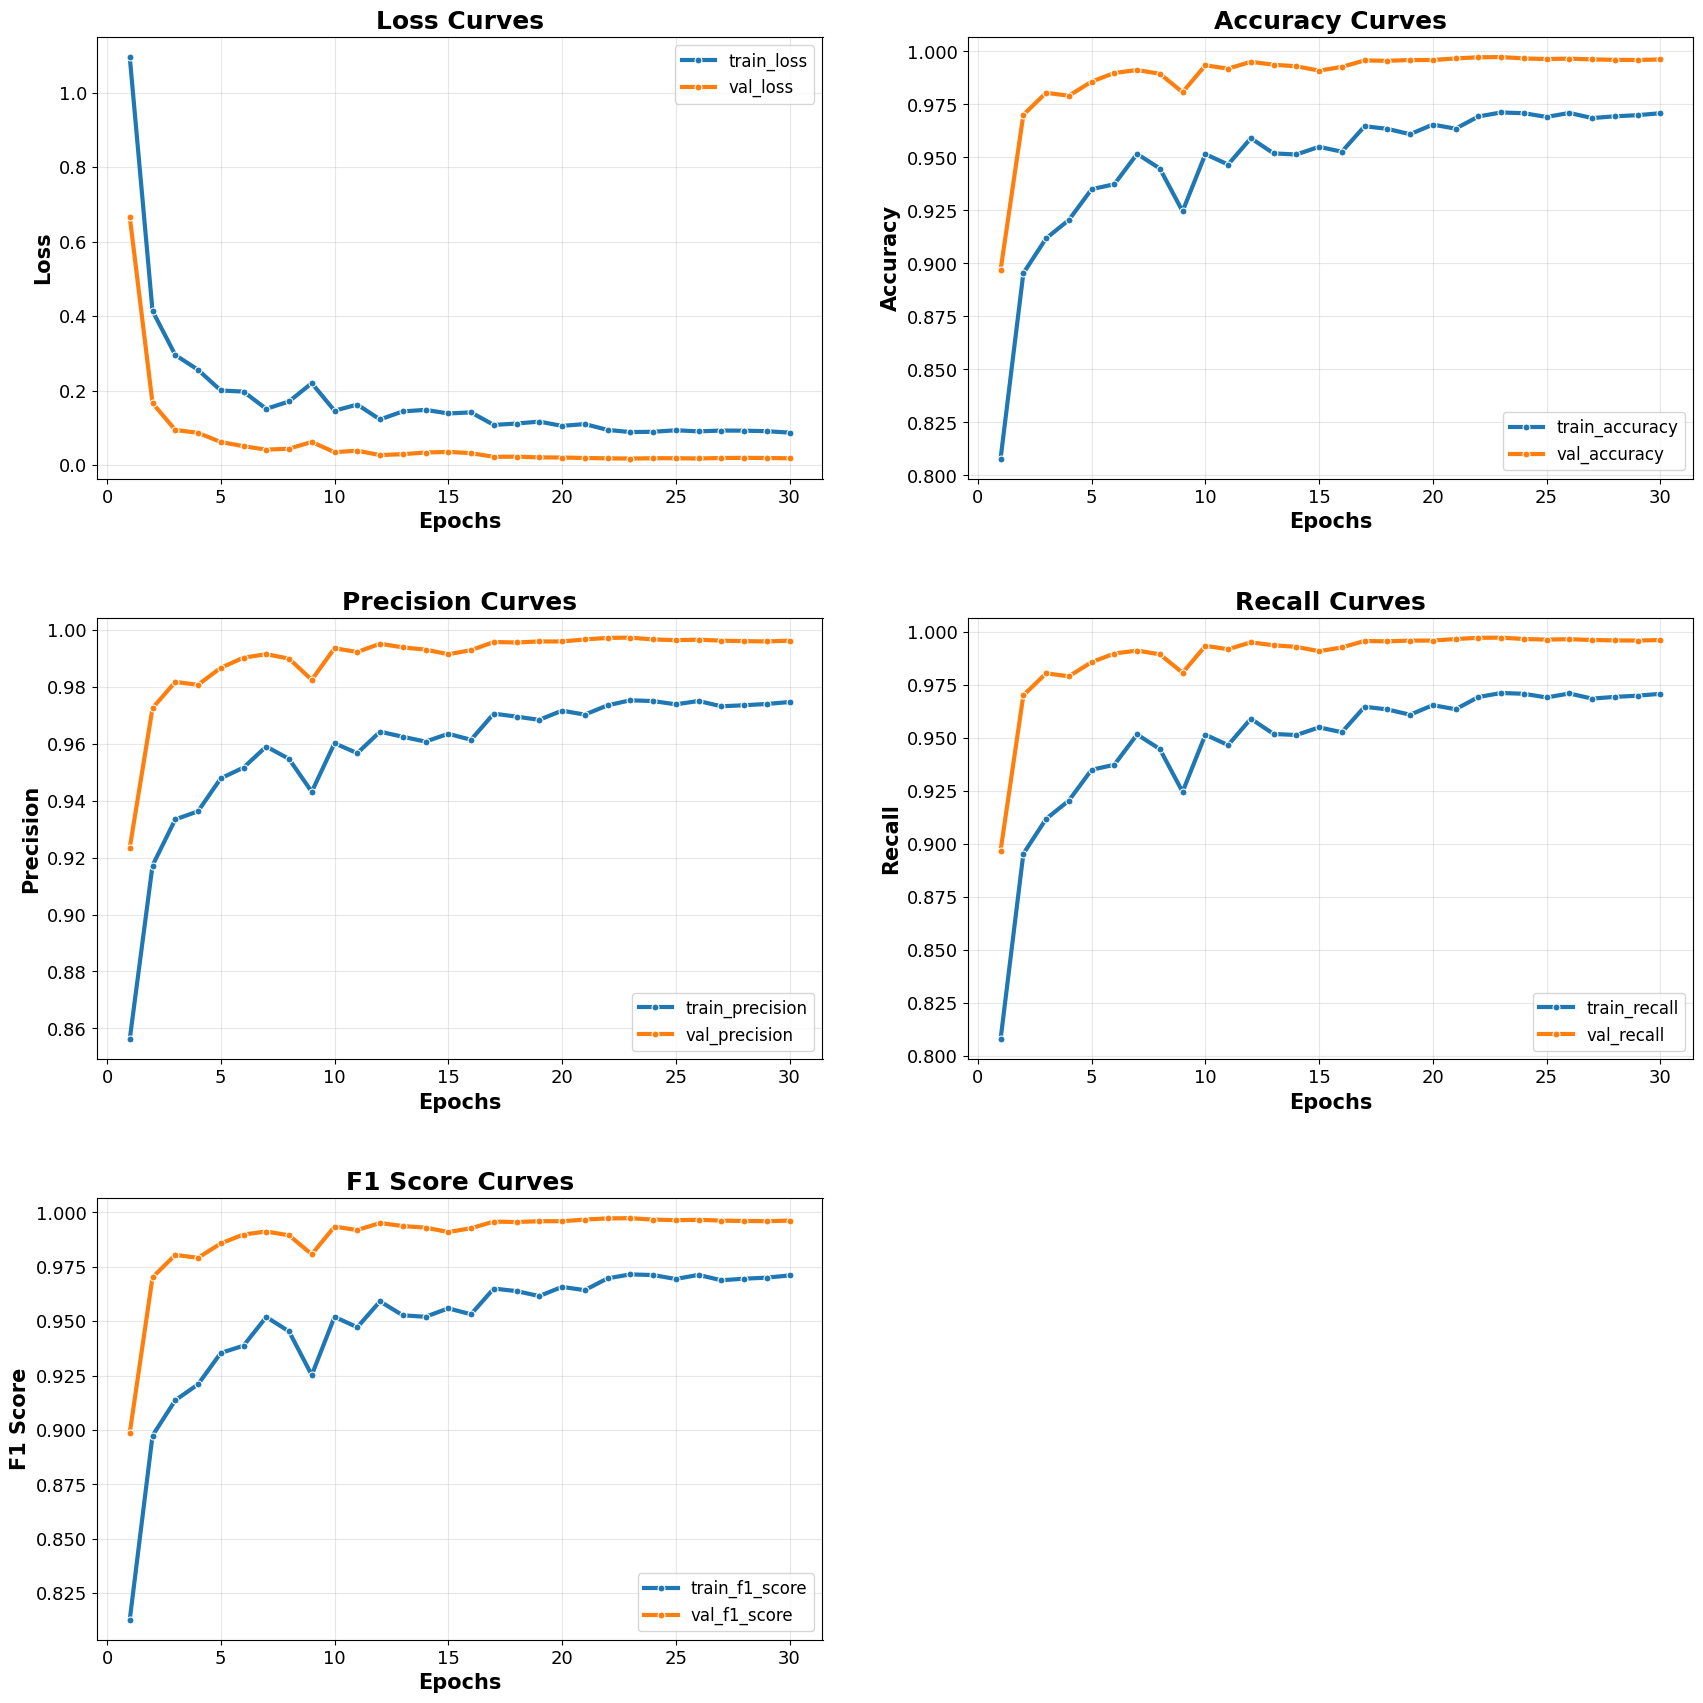

In [16]:
gen_line_charts(metrics, "../documentations/experiments/anuj-yolo", "training_metrics_graph.png", ["train_", "val_"])

In [17]:
# Find best models
def find_best_models(df):
    best = df[df["val_accuracy"] == df["val_accuracy"].max()] # combines and remove duplicates
    return best

find_best_models(metrics)

,epoch,checkpoint,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
22,23,epoch22.pt,0.088474,0.017428,0.971197,0.975317,0.971197,0.971476,0.997315,0.997349,0.997315,0.997315
